# Vision Transformer (ViT) – CIFAR-100 Image Classification

This notebook fine-tunes an ImageNet-pretrained Vision Transformer on CIFAR-100, a 100-class image classification dataset. The previous from-scratch model reached about 51% validation accuracy and showed a large training-to-validation gap. This revision switches to transfer learning, uses 224×224 inputs expected by the pretrained model, applies stronger data augmentation, separates the learning rates for the pretrained backbone and new classifier head, and uses warmup followed by cosine decay. Training output is limited to one summary line per epoch. The intended runtime is Google Colab with an NVIDIA Tesla T4 GPU; actual performance depends on the runtime and training duration.


## 1. Install Libraries and Check Runtime
Install `timm` when necessary and verify the Python, PyTorch, CUDA, and GPU environment.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("timm") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])

import os
import random
import math
import platform
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {__import__('torchvision').__version__}")
print(f"timm: {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    torch.set_float32_matmul_precision("high")
else:
    print("GPU: CPU; training at 224×224 will be considerably slower")


Python: 3.13.15
PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
timm: 1.0.30
CUDA available: True
GPU: Tesla T4
CUDA version: 13.0


## 2. Configure Reproducibility and Training
Set data split, fine-tuning, augmentation, checkpoint, and logging options for a reproducible run.

In [2]:
SEED = 42
NUM_CLASSES = 100
IMAGE_SIZE = 224
VAL_SIZE = 5000
BATCH_SIZE = 64
NUM_WORKERS = 2
EPOCHS = 15
BACKBONE_LEARNING_RATE = 3e-5
HEAD_LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
WARMUP_FRACTION = 0.05
MODEL_NAME = "hf_hub:timm/vit_small_patch16_224.augreg_in21k_ft_in1k"
DATA_DIR = Path("/content/data")
RUN_DIR = Path("/content/vit_cifar100_transfer_runs")
CHECKPOINT_PATH = RUN_DIR / "best_model.pth"
METADATA_PATH = RUN_DIR / "model_metadata.json"

RUN_DIR.mkdir(parents=True, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
NUM_WORKERS = NUM_WORKERS if DEVICE.type == "cuda" else 0

config = pd.Series({
    "Model": MODEL_NAME,
    "Pretraining": "ImageNet-21k pretraining and ImageNet-1k fine-tuning",
    "Image size": IMAGE_SIZE,
    "Batch size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Backbone learning rate": BACKBONE_LEARNING_RATE,
    "Classifier learning rate": HEAD_LEARNING_RATE,
    "Weight decay": WEIGHT_DECAY,
    "Label smoothing": LABEL_SMOOTHING,
    "Warmup fraction": WARMUP_FRACTION,
    "Mixed precision": USE_AMP,
    "DataLoader workers": NUM_WORKERS,
    "Device": str(DEVICE)
}, name="Value")
print(config.to_string())


Model                       hf_hub:timm/vit_small_patch16_224.augreg_in21k...
Pretraining                 ImageNet-21k pretraining and ImageNet-1k fine-...
Image size                                                                224
Batch size                                                                 64
Epochs                                                                     15
Backbone learning rate                                                0.00003
Classifier learning rate                                               0.0003
Weight decay                                                             0.05
Label smoothing                                                           0.1
Warmup fraction                                                          0.05
Mixed precision                                                          True
DataLoader workers                                                          2
Device                                                          

## 3. Load CIFAR-100 and Create Dataset Splits
Use 45,000 images for training, 5,000 for validation, and the official 10,000-image test set.

In [3]:
NORM_MEAN = (0.5, 0.5, 0.5)
NORM_STD = (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=7, interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random")
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE / 0.9), interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

class CIFAR100TransformedSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform
        self.classes = base_dataset.classes

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        source_index = self.indices[index]
        image = Image.fromarray(self.base_dataset.data[source_index])
        label = int(self.base_dataset.targets[source_index])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

base_train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True)
base_test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True)
class_names = base_train_dataset.classes

split_generator = torch.Generator().manual_seed(SEED)
permuted_indices = torch.randperm(len(base_train_dataset), generator=split_generator).tolist()
val_indices = permuted_indices[:VAL_SIZE]
train_indices = permuted_indices[VAL_SIZE:]
test_indices = list(range(len(base_test_dataset)))

train_dataset = CIFAR100TransformedSubset(base_train_dataset, train_indices, train_transform)
val_dataset = CIFAR100TransformedSubset(base_train_dataset, val_indices, eval_transform)
test_dataset = CIFAR100TransformedSubset(base_test_dataset, test_indices, eval_transform)

loader_options = {
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0
}
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, **loader_options)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_options)

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Images": [len(train_dataset), len(val_dataset), len(test_dataset)]
})
print(split_summary.to_string(index=False))
print(f"Number of classes: {len(class_names)}")
print(f"Input tensor shape: (3, {IMAGE_SIZE}, {IMAGE_SIZE})")


100%|██████████| 169M/169M [31:10<00:00, 90.3kB/s]


     Split  Images
  Training   45000
Validation    5000
      Test   10000
Number of classes: 100
Input tensor shape: (3, 224, 224)


## 4. Inspect the Dataset
Display augmented training images and confirm the labels and class mapping.

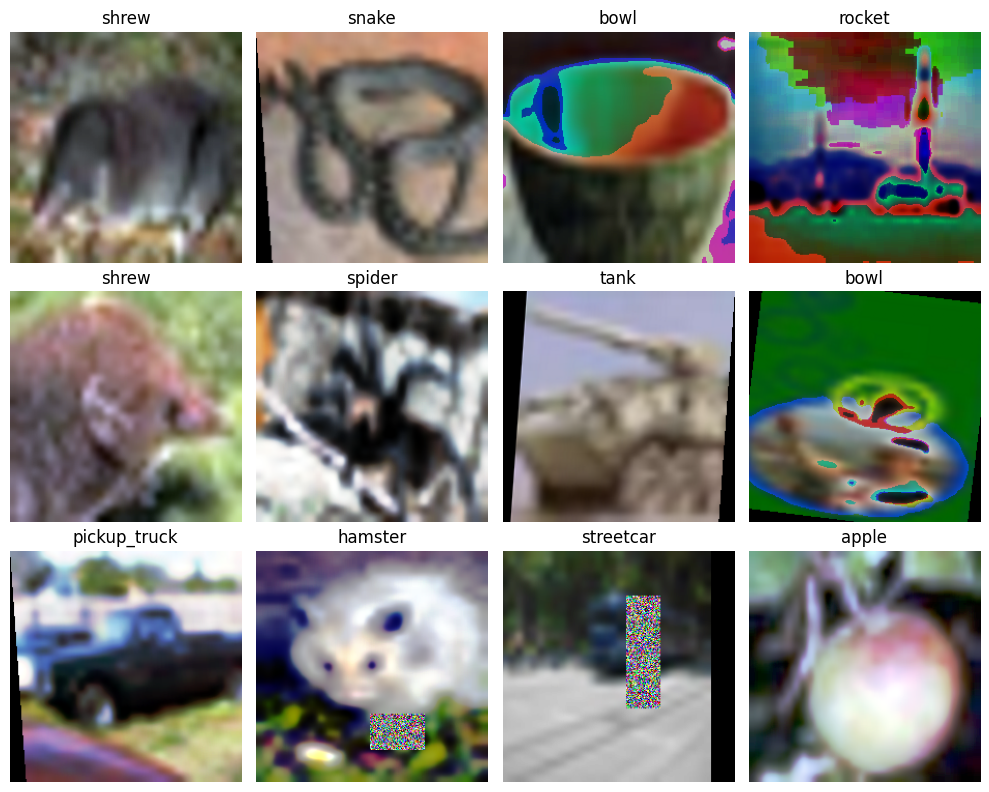

First 20 classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle']


In [4]:
images, labels = next(iter(DataLoader(train_dataset, batch_size=12, shuffle=True, num_workers=0)))
images_for_plot = (images[:12].cpu() * torch.tensor(NORM_STD).view(1, 3, 1, 1) + torch.tensor(NORM_MEAN).view(1, 3, 1, 1)).clamp(0, 1)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_for_plot[i].permute(1, 2, 0))
    ax.set_title(class_names[int(labels[i])])
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"First 20 classes: {class_names[:20]}")


## 5. Load the Pretrained Vision Transformer
Initialize a pretrained ViT-Small backbone and replace its classification head with a 100-class head.

In [5]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.1,
    drop_path_rate=0.1
)
model = model.to(DEVICE)
model_data_config = timm.data.resolve_model_data_config(model)

print(f"Model: {MODEL_NAME}")
print(f"Expected input size: {model_data_config['input_size']}")
print(f"Pretrained normalization mean: {model_data_config['mean']}")
print(f"Pretrained normalization std: {model_data_config['std']}")
print(f"Image size configured: {IMAGE_SIZE}")
print(f"Classification classes: {NUM_CLASSES}")


config.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Model: hf_hub:timm/vit_small_patch16_224.augreg_in21k_ft_in1k
Expected input size: [3, 224, 224]
Pretrained normalization mean: [0.5, 0.5, 0.5]
Pretrained normalization std: [0.5, 0.5, 0.5]
Image size configured: 224
Classification classes: 100


## 6. Inspect Model Architecture
Check parameter counts and output dimensions before starting fine-tuning.

In [6]:
total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
head_parameters = list(model.get_classifier().parameters())
head_parameter_ids = {id(parameter) for parameter in head_parameters}
backbone_parameters = [parameter for parameter in model.parameters() if id(parameter) not in head_parameter_ids]

with torch.no_grad():
    dummy_output = model(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE))

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Backbone parameter tensors: {len(backbone_parameters)}")
print(f"Classifier parameter tensors: {len(head_parameters)}")
print(f"Output shape: {tuple(dummy_output.shape)}")


Total parameters: 21,704,164
Trainable parameters: 21,704,164
Backbone parameter tensors: 150
Classifier parameter tensors: 2
Output shape: (2, 100)


## 7. Prepare Training Utilities
Use separate backbone and classifier learning rates, smoothed cross-entropy, gradient clipping, mixed precision, and step-based warmup with cosine decay.

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(
    [
        {"params": backbone_parameters, "lr": BACKBONE_LEARNING_RATE},
        {"params": head_parameters, "lr": HEAD_LEARNING_RATE}
    ],
    weight_decay=WEIGHT_DECAY
)

TOTAL_STEPS = EPOCHS * len(train_loader)
WARMUP_STEPS = max(1, int(TOTAL_STEPS * WARMUP_FRACTION))

def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return 0.1 + 0.9 * current_step / WARMUP_STEPS
    cosine_progress = (current_step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    cosine_progress = min(max(cosine_progress, 0.0), 1.0)
    return 0.5 * (1.0 + math.cos(math.pi * cosine_progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.set_grad_enabled(training):
        for batch_images, batch_targets in loader:
            batch_images = batch_images.to(DEVICE, non_blocking=True)
            batch_targets = batch_targets.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                logits = model(batch_images)
                loss = criterion(logits, batch_targets)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            batch_size = batch_targets.size(0)
            total_loss += loss.detach().item() * batch_size
            total_correct += (logits.detach().argmax(dim=1) == batch_targets).sum().item()
            total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Total optimizer steps: {TOTAL_STEPS:,}")
print(f"Warmup steps: {WARMUP_STEPS:,}")
print("Training logs will print once per epoch; batch-level progress output is disabled.")


Training batches per epoch: 704
Total optimizer steps: 10,560
Warmup steps: 528
Training logs will print once per epoch; batch-level progress output is disabled.


## 8. Train and Validate the Model
Fine-tune the pretrained model, report one concise summary per epoch, and save the checkpoint with the best validation accuracy.

In [8]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "backbone_learning_rate": [],
    "head_learning_rate": []
}
best_val_accuracy = -1.0
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(model, train_loader, optimizer)
    val_loss, val_accuracy = run_epoch(model, val_loader)
    backbone_lr = optimizer.param_groups[0]["lr"]
    head_lr = optimizer.param_groups[1]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["backbone_learning_rate"].append(backbone_lr)
    history["head_learning_rate"].append(head_lr)

    checkpoint_note = ""
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": best_epoch,
            "best_val_accuracy": best_val_accuracy,
            "class_names": class_names,
            "model_name": MODEL_NAME,
            "image_size": IMAGE_SIZE
        }, CHECKPOINT_PATH)
        checkpoint_note = " | best checkpoint saved"

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss {train_loss:.4f} | Train acc {train_accuracy:.4f} | "
        f"Val loss {val_loss:.4f} | Val acc {val_accuracy:.4f} | "
        f"Backbone LR {backbone_lr:.2e} | Head LR {head_lr:.2e}{checkpoint_note}"
    )

history_df = pd.DataFrame(history, index=np.arange(1, EPOCHS + 1))
history_df.index.name = "epoch"


Epoch 01/15 | Train loss 2.7082 | Train acc 0.4927 | Val loss 1.2306 | Val acc 0.8688 | Backbone LR 3.00e-05 | Head LR 3.00e-04 | best checkpoint saved
Epoch 02/15 | Train loss 1.4286 | Train acc 0.8072 | Val loss 1.1555 | Val acc 0.8906 | Backbone LR 2.94e-05 | Head LR 2.94e-04 | best checkpoint saved
Epoch 03/15 | Train loss 1.2957 | Train acc 0.8463 | Val loss 1.1294 | Val acc 0.9046 | Backbone LR 2.82e-05 | Head LR 2.82e-04 | best checkpoint saved
Epoch 04/15 | Train loss 1.2167 | Train acc 0.8701 | Val loss 1.1072 | Val acc 0.9066 | Backbone LR 2.63e-05 | Head LR 2.63e-04 | best checkpoint saved
Epoch 05/15 | Train loss 1.1630 | Train acc 0.8859 | Val loss 1.0865 | Val acc 0.9086 | Backbone LR 2.39e-05 | Head LR 2.39e-04 | best checkpoint saved
Epoch 06/15 | Train loss 1.1171 | Train acc 0.9009 | Val loss 1.0835 | Val acc 0.9060 | Backbone LR 2.10e-05 | Head LR 2.10e-04
Epoch 07/15 | Train loss 1.0899 | Train acc 0.9092 | Val loss 1.0699 | Val acc 0.9114 | Backbone LR 1.79e-05 | H

## 9. Inspect Training History
Identify the best validation epoch and compare the final training state with the best checkpoint.

In [9]:
best_epoch = int(history_df["val_accuracy"].idxmax())
best_val_accuracy = float(history_df.loc[best_epoch, "val_accuracy"])
print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Training accuracy at best epoch: {history_df.loc[best_epoch, 'train_accuracy']:.4f}")
print(f"Validation loss at best epoch: {history_df.loc[best_epoch, 'val_loss']:.4f}")
print(f"Final training accuracy: {history_df['train_accuracy'].iloc[-1]:.4f}")
print(f"Final validation accuracy: {history_df['val_accuracy'].iloc[-1]:.4f}")
print(f"Checkpoint: {CHECKPOINT_PATH}")


Best epoch: 14
Best validation accuracy: 0.9222
Training accuracy at best epoch: 0.9492
Validation loss at best epoch: 1.0412
Final training accuracy: 0.9502
Final validation accuracy: 0.9222
Checkpoint: /content/vit_cifar100_transfer_runs/best_model.pth


## 10. Plot Training and Validation Metrics
Visualize loss, accuracy, and the learning-rate schedule to check convergence and overfitting.

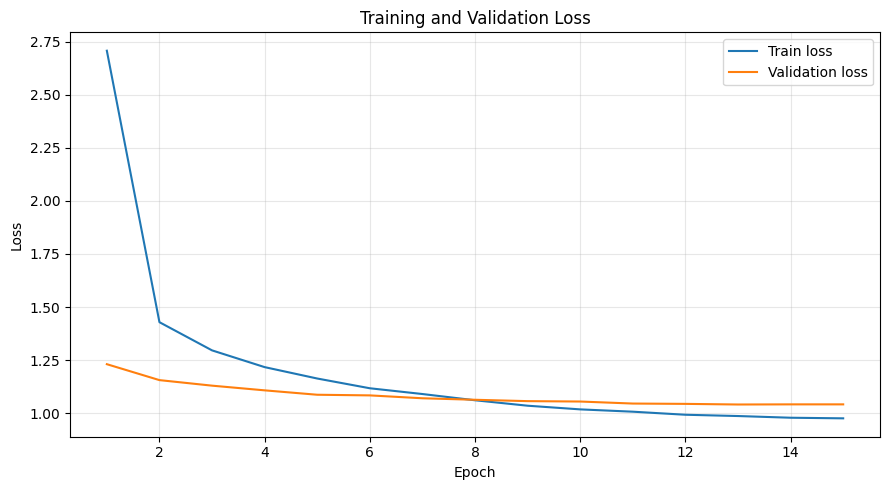

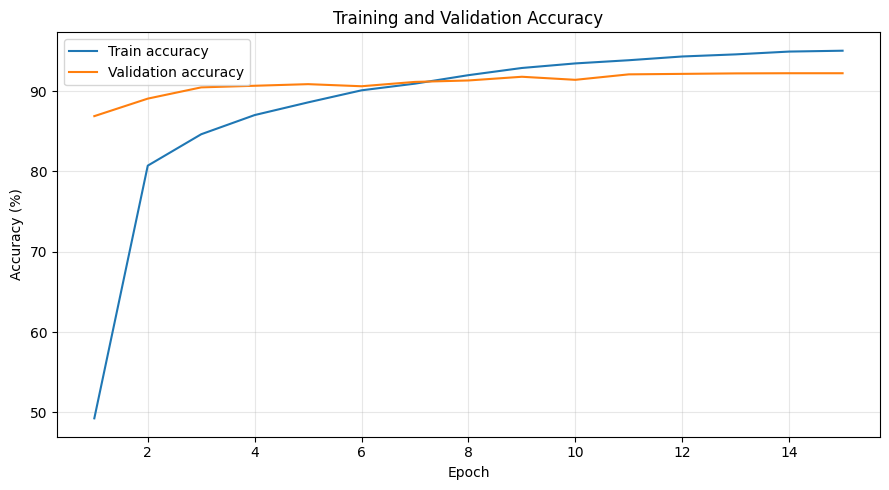

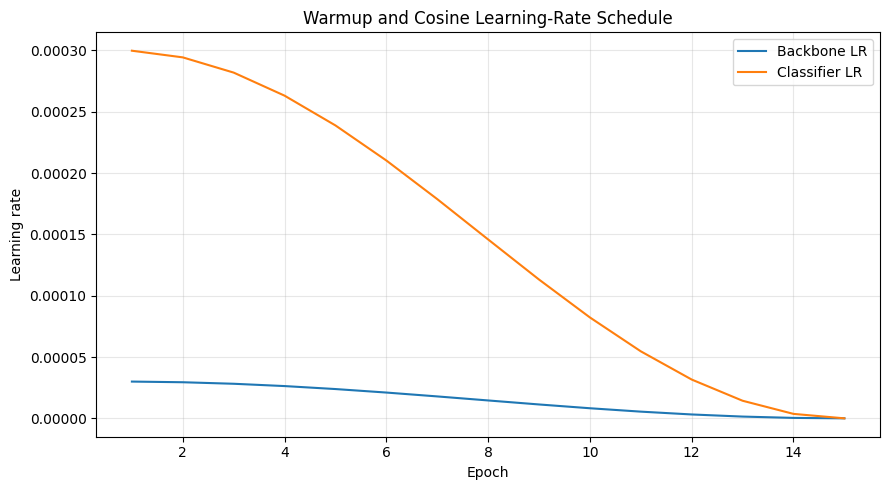

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df.index, history_df["train_loss"], label="Train loss")
ax.plot(history_df.index, history_df["val_loss"], label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df.index, history_df["train_accuracy"] * 100, label="Train accuracy")
ax.plot(history_df.index, history_df["val_accuracy"] * 100, label="Validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Training and Validation Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df.index, history_df["backbone_learning_rate"], label="Backbone LR")
ax.plot(history_df.index, history_df["head_learning_rate"], label="Classifier LR")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("Warmup and Cosine Learning-Rate Schedule")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Load the Best Checkpoint
Restore the best validation checkpoint before running the final test evaluation.

In [11]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
best_epoch = int(checkpoint["epoch"])
best_val_accuracy = float(checkpoint["best_val_accuracy"])
print(f"Loaded checkpoint from epoch {best_epoch}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")


Loaded checkpoint from epoch 14
Best validation accuracy: 0.9222


## 12. Evaluate on the Test Set
Evaluate the chosen checkpoint once on the official test split and collect predictions for analysis.

In [12]:
model.eval()
all_test_targets = []
all_test_predictions = []
all_test_confidences = []
test_loss_sum = 0.0
test_examples = 0

with torch.no_grad():
    for batch_images, batch_targets in test_loader:
        batch_images = batch_images.to(DEVICE, non_blocking=True)
        batch_targets_device = batch_targets.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits = model(batch_images)
            loss = criterion(logits, batch_targets_device)
        probabilities = F.softmax(logits, dim=1)
        confidences, predictions = probabilities.max(dim=1)

        batch_size = batch_targets_device.size(0)
        test_loss_sum += loss.item() * batch_size
        test_examples += batch_size
        all_test_targets.extend(batch_targets.numpy().tolist())
        all_test_predictions.extend(predictions.cpu().numpy().tolist())
        all_test_confidences.extend(confidences.float().cpu().numpy().tolist())

all_test_targets = np.asarray(all_test_targets, dtype=np.int64)
all_test_predictions = np.asarray(all_test_predictions, dtype=np.int64)
all_test_confidences = np.asarray(all_test_confidences, dtype=np.float32)
test_loss = test_loss_sum / test_examples
test_accuracy = accuracy_score(all_test_targets, all_test_predictions)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Correct predictions: {(all_test_predictions == all_test_targets).sum():,}/{len(test_dataset):,}")


Test loss: 1.0324
Test accuracy: 0.9192
Correct predictions: 9,192/10,000


## 13. Summarize Classification Metrics
Calculate accuracy, macro precision, macro recall, macro F1, and weighted F1 on the complete test set.

In [ ]:
test_precision = precision_score(all_test_targets, all_test_predictions, average="macro", zero_division=0)
test_recall = recall_score(all_test_targets, all_test_predictions, average="macro", zero_division=0)
test_macro_f1 = f1_score(all_test_targets, all_test_predictions, average="macro", zero_division=0)
test_weighted_f1 = f1_score(all_test_targets, all_test_predictions, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Test Macro Precision",
        "Test Macro Recall",
        "Test Macro F1",
        "Test Weighted F1"
    ],
    "Value": [
        test_loss,
        test_accuracy,
        test_precision,
        test_recall,
        test_macro_f1,
        test_weighted_f1
    ]
})
print(metrics_df.to_string(index=False, formatters={"Value": "{:.4f}".format}))


## 14. Analyze Class-wise Performance
Review the strongest and weakest classes by F1 score to identify which categories remain difficult.

In [ ]:
report = classification_report(
    all_test_targets,
    all_test_predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
class_report_df = pd.DataFrame(report).T
class_report_df = class_report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]
class_report_df = class_report_df.sort_values("f1-score", ascending=False)

print("Top 10 classes by F1 score")
print(class_report_df.head(10).to_string(float_format=lambda value: f"{value:.3f}"))
print("\nBottom 10 classes by F1 score")
print(class_report_df.tail(10).sort_values("f1-score").to_string(float_format=lambda value: f"{value:.3f}"))


## 15. Plot the Confusion Matrix
Visualize normalized class confusion to inspect frequent errors across the 100 CIFAR-100 categories.

In [ ]:
cm = confusion_matrix(all_test_targets, all_test_predictions, labels=np.arange(NUM_CLASSES), normalize="true")
fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(cm, interpolation="nearest", aspect="auto")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=90, fontsize=6)
ax.set_yticklabels(class_names, fontsize=6)
plt.tight_layout()
plt.show()


## 16. Select Test Images
Choose a fixed sample of correct and incorrect predictions for visual inspection.

In [ ]:
rng = np.random.default_rng(SEED)
all_indices = np.arange(len(test_dataset))
correct_indices = all_indices[all_test_predictions == all_test_targets]
incorrect_indices = all_indices[all_test_predictions != all_test_targets]
sample_correct = rng.choice(correct_indices, size=min(6, len(correct_indices)), replace=False)
sample_incorrect = rng.choice(incorrect_indices, size=min(6, len(incorrect_indices)), replace=False) if len(incorrect_indices) else np.array([], dtype=int)
sample_indices = np.concatenate([sample_correct, sample_incorrect])

print(f"Correct test predictions: {len(correct_indices):,}")
print(f"Incorrect test predictions: {len(incorrect_indices):,}")
print(f"Selected images: {len(sample_indices)}")


## 17. Run Sample Predictions
Collect predicted labels and confidence scores for the selected images using the best checkpoint.

In [17]:
sample_images = []
sample_true = []
sample_pred = []
sample_conf = []

model.eval()
with torch.no_grad():
    for index in sample_indices:
        image, target = test_dataset[int(index)]
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits = model(image.unsqueeze(0).to(DEVICE))
        probabilities = F.softmax(logits, dim=1)
        confidence, prediction = probabilities.max(dim=1)
        sample_images.append(image)
        sample_true.append(int(target))
        sample_pred.append(int(prediction.item()))
        sample_conf.append(float(confidence.item()))

sample_predictions_df = pd.DataFrame({
    "Index": sample_indices,
    "True label": [class_names[index] for index in sample_true],
    "Predicted label": [class_names[index] for index in sample_pred],
    "Confidence": sample_conf
})
print(sample_predictions_df.to_string(index=False, formatters={"Confidence": "{:.3f}".format}))


 Index  True label Predicted label Confidence
  6541      beetle          beetle      0.935
  7741       couch           couch      0.957
  4325      bottle          bottle      0.954
  8581   sunflower       sunflower      0.924
  4388      spider          spider      0.936
   875   butterfly       butterfly      0.888
  7480    flatfish   aquarium_fish      0.533
  5105       otter          beaver      0.529
  7178 willow_tree      maple_tree      0.700
  7346         boy            girl      0.690
  7793    dinosaur       crocodile      0.653
  9758    kangaroo          rabbit      0.353


## 18. Visualize Predictions
Display selected test images with predicted class, true class, and confidence score.

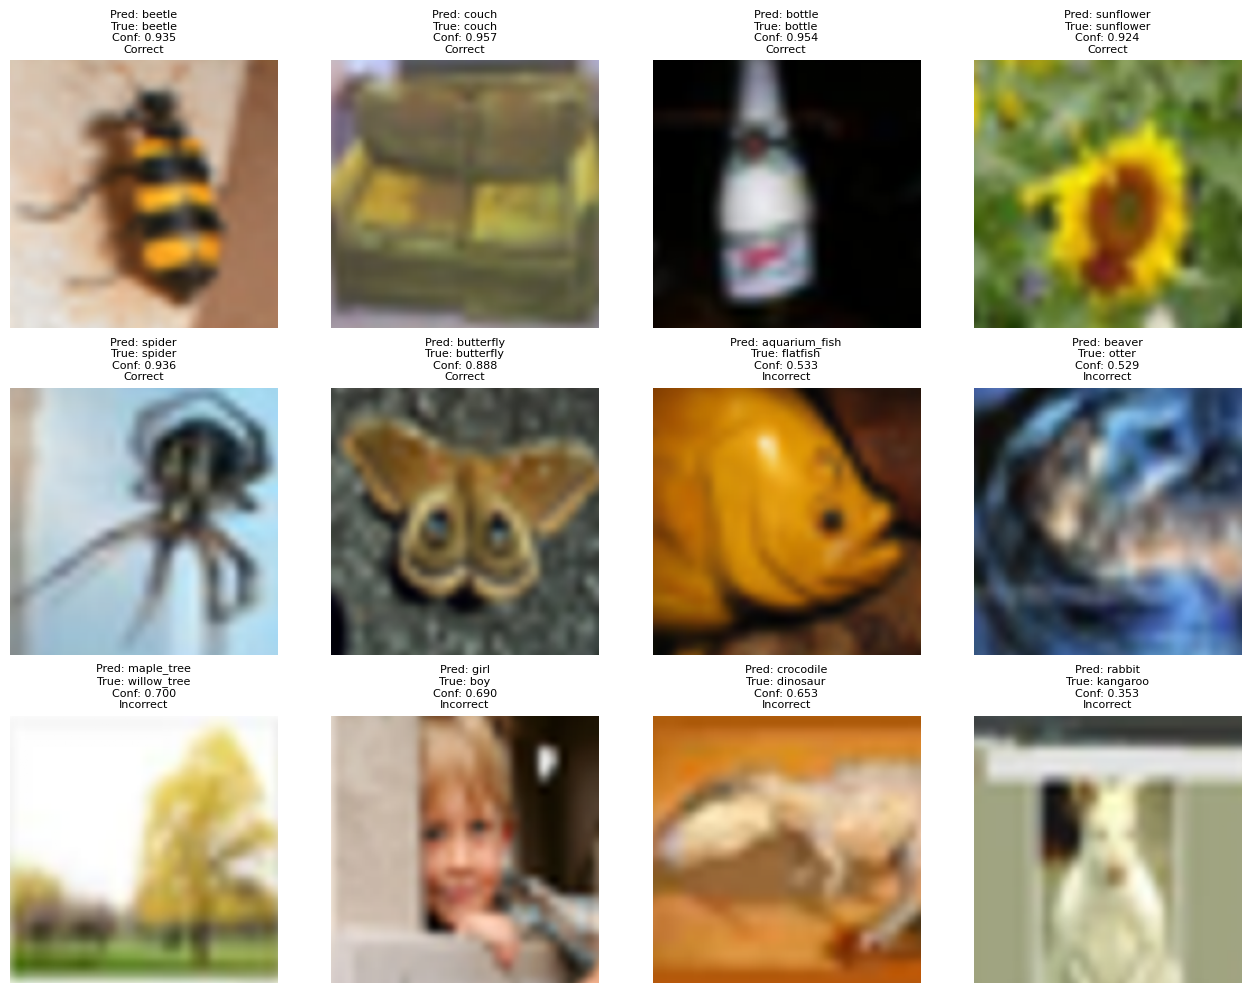

In [18]:
plot_mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
plot_std = torch.tensor(NORM_STD).view(3, 1, 1)
fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for index, ax in enumerate(axes.flat):
    if index < len(sample_images):
        image = (sample_images[index].cpu() * plot_std + plot_mean).clamp(0, 1)
        is_correct = sample_true[index] == sample_pred[index]
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(
            f"Pred: {class_names[sample_pred[index]]}\nTrue: {class_names[sample_true[index]]}\nConf: {sample_conf[index]:.3f}\n{'Correct' if is_correct else 'Incorrect'}",
            fontsize=8
        )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 19. Inspect Prediction Confidence
Compare confidence statistics for correct and incorrect predictions to see how confidence relates to classification errors.

    Group  Mean confidence  Median confidence  Minimum confidence  Maximum confidence
      All           0.8635             0.9219              0.0888              0.9941
  Correct           0.8863             0.9253              0.1398              0.9941
Incorrect           0.6044             0.5974              0.0888              0.9839


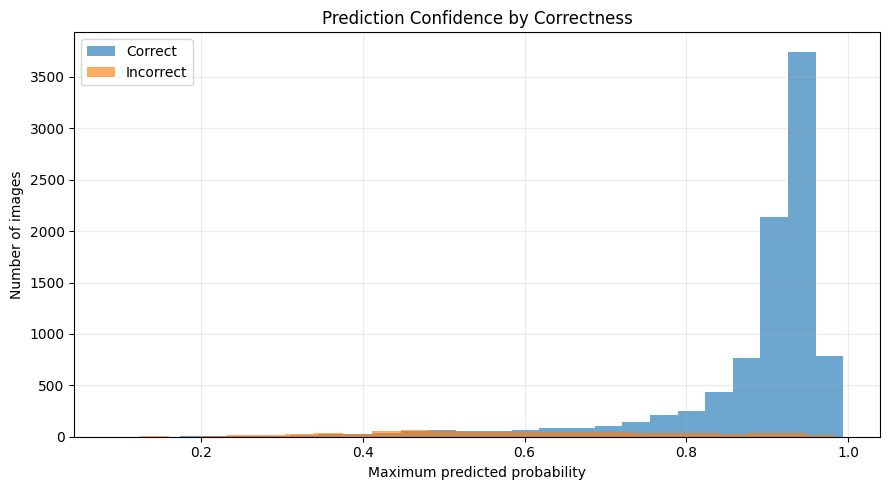

In [19]:
correct_mask = all_test_predictions == all_test_targets
incorrect_mask = ~correct_mask

confidence_summary = pd.DataFrame({
    "Group": ["All", "Correct", "Incorrect"],
    "Mean confidence": [
        all_test_confidences.mean(),
        all_test_confidences[correct_mask].mean() if correct_mask.any() else np.nan,
        all_test_confidences[incorrect_mask].mean() if incorrect_mask.any() else np.nan
    ],
    "Median confidence": [
        np.median(all_test_confidences),
        np.median(all_test_confidences[correct_mask]) if correct_mask.any() else np.nan,
        np.median(all_test_confidences[incorrect_mask]) if incorrect_mask.any() else np.nan
    ],
    "Minimum confidence": [
        all_test_confidences.min(),
        all_test_confidences[correct_mask].min() if correct_mask.any() else np.nan,
        all_test_confidences[incorrect_mask].min() if incorrect_mask.any() else np.nan
    ],
    "Maximum confidence": [
        all_test_confidences.max(),
        all_test_confidences[correct_mask].max() if correct_mask.any() else np.nan,
        all_test_confidences[incorrect_mask].max() if incorrect_mask.any() else np.nan
    ]
})
print(confidence_summary.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(all_test_confidences[correct_mask], bins=25, alpha=0.65, label="Correct")
ax.hist(all_test_confidences[incorrect_mask], bins=25, alpha=0.65, label="Incorrect")
ax.set_xlabel("Maximum predicted probability")
ax.set_ylabel("Number of images")
ax.set_title("Prediction Confidence by Correctness")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 20. References and Result Context
The training recipe follows a pretrained-transfer-learning approach rather than training the ViT from random initialization. The public references below report results for related configurations; their scores should not be treated as the expected or guaranteed score of this notebook.

- [ViT CIFAR-100 reproduction repository](https://github.com/Wydoinn/vit-cifar100-reproduction): reports 85.52% test accuracy for a pretrained ViT-Base/16 using 224×224 inputs, batch size 64, and 15 epochs.
- [Pretrained ViT-Small model card](https://huggingface.co/timm/vit_small_patch16_224.augreg_in21k_ft_in1k): ImageNet-21k-pretrained and ImageNet-1k-fine-tuned checkpoint used as this notebook's starting point.
- [Google Research Vision Transformer repository](https://github.com/google-research/vision_transformer): original implementation and published CIFAR-100 transfer-learning results.

## 21. Key Findings

## 22. Conclusion